In [22]:
# imports + setup

import glob
import os
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

results_date = '2026-09-21'

result_files = sorted(glob.glob(f'results/{results_date}/T_*.pkl'))
save_path = Path(f'figures/{results_date}')
save_path.mkdir(parents=True, exist_ok=True)

In [23]:
# --- load + process all results (run once, reused by every plot below) ---

def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

records = []
for path in result_files:
    # the filename encodes T_hat -- simulation.py writes f'{T_hat:.2f}' --
    # not the T that create_new actually used (T = T_hat * ln(N)).
    T_hat = float(re.search(r'T_(\d+p\d+)\.pkl', path).group(1).replace('p', '.'))
    data = load_results(path)

    sizes = sorted(data.keys())
    medians, q25s, q75s, q_by_size = [], [], [], []
    all_q = []
    tree_depth_by_size, T_cal_by_size = [], []
    span_mean_by_size, span_std_by_size, span_pcts_by_size = [], [], []
    bucket_sizes_by_size = []
    for N in sizes:
        conv_times = [trial['predicted_convergence_time'] for trial in data[N]]
        medians.append(np.median(conv_times))
        q25s.append(np.percentile(conv_times, 25))
        q75s.append(np.percentile(conv_times, 75))
        trial_q = [trial['trophic_incoherence'] for trial in data[N]]
        q_by_size.append(np.mean(trial_q))
        all_q.extend(trial_q)

        # --- extra returns from create_new ---
        tree_depth_by_size.append(
            np.mean([trial['tree_depth'] for trial in data[N]]))
        T_cal_by_size.append(
            np.mean([trial['T_calibrated'] for trial in data[N]]))

        # normalized_level_spans is one value per EDGE, so pooling the raw
        # arrays across every (T, N, trial) would run to hundreds of millions
        # of floats. Summarise per N here and let the array go.
        spans = np.concatenate(
            [np.asarray(trial['normalized_level_spans']) for trial in data[N]])
        span_mean_by_size.append(spans.mean())
        span_std_by_size.append(spans.std())
        span_pcts_by_size.append(np.percentile(spans, [25, 50, 75]))

        # bucket_sizes is a small (sl, tl, size) DataFrame per trial
        bucket_sizes_by_size.append([trial['bucket_sizes'] for trial in data[N]])

    # NOTE: sizes are averaged over here
    q_mean = np.mean(all_q)
    alpha, intercept = np.polyfit(np.log(sizes), np.log(medians), 1)

    records.append({
        'path': path,
        'T_hat': T_hat,
        'T_by_size': T_cal_by_size,   # actual T per N, as run
        'q_mean': q_mean,
        'sizes': sizes,
        'medians': medians,
        'q25s': q25s,
        'q75s': q75s,
        'q_by_size': q_by_size,
        'alpha': alpha,
        'prefactor': np.exp(intercept),
        'tree_depth_by_size': tree_depth_by_size,
        'T_cal_by_size': T_cal_by_size,
        'span_mean_by_size': span_mean_by_size,
        'span_std_by_size': span_std_by_size,
        'span_pcts_by_size': np.array(span_pcts_by_size),
        'bucket_sizes_by_size': bucket_sizes_by_size,
    })

records_by_T_hat = sorted(records, key=lambda r: r['T_hat'])
records_by_q = sorted(records, key=lambda r: r['q_mean'])

T_hat_values = np.array([r['T_hat'] for r in records_by_T_hat])
q_means = np.array([r['q_mean'] for r in records_by_T_hat])
exponents = np.array([r['alpha'] for r in records_by_T_hat])
prefactors = np.array([r['prefactor'] for r in records_by_T_hat])

sizes_grid = np.array(records_by_T_hat[0]['sizes'])

# (T, N) grids for the extra returns, same orientation as sizes_grid
tree_depths = np.array([r['tree_depth_by_size'] for r in records_by_T_hat])
T_calibrated = np.array([r['T_cal_by_size'] for r in records_by_T_hat])
span_means = np.array([r['span_mean_by_size'] for r in records_by_T_hat])
span_stds = np.array([r['span_std_by_size'] for r in records_by_T_hat])

# --- T_hat vs actual T ---------------------------------------------------
# generator.py sets T = T_hat * ln(N), so the actual T rises with N along every
# fixed-T_hat curve; there is no single T per results file. T_grid holds the T
# each (T_hat, N) cell actually ran at, taken from the stored T_calibrated
# rather than recomputed, so it stays correct for runs that predate a formula
# change.
T_grid = np.array([r['T_by_size'] for r in records_by_T_hat])

_expected = T_hat_values[:, None] * np.log(sizes_grid)[None, :]
if not np.allclose(T_grid, _expected, rtol=1e-6):
    print('WARNING: stored T_calibrated does not match T_hat * ln(N) -- these '
          'results predate the current T formula in generator.py.')
    print(f'  stored   T[0] = {np.round(T_grid[0], 4)}')
    print(f'  expected T[0] = {np.round(_expected[0], 4)}')
    print('  plots below use the stored values.')

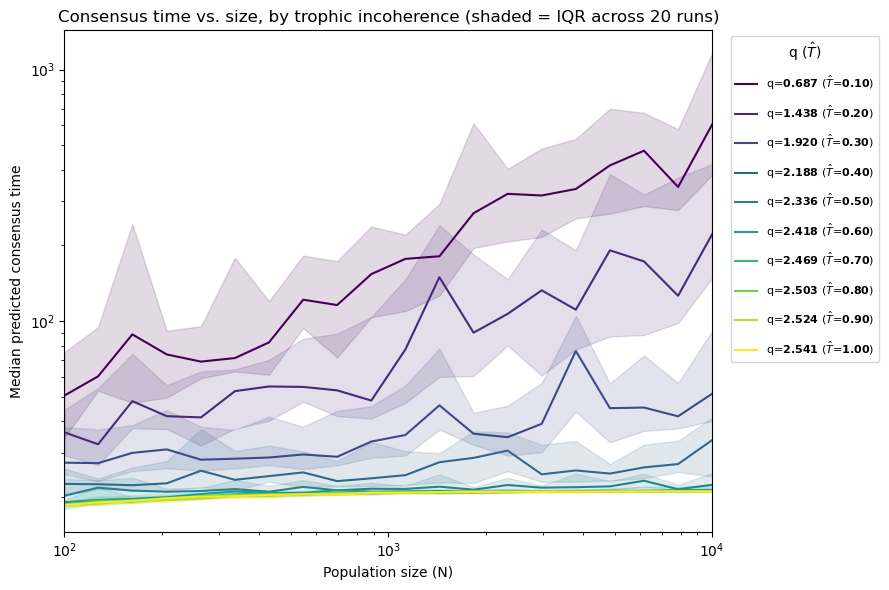

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('viridis')

for i, r in enumerate(records_by_q):
    color = cmap(i / max(len(records_by_q) - 1, 1))
    ax.plot(r['sizes'], r['medians'],
            label=fr'q=$\bf{{{r["q_mean"]:.3f}}}$ ($\hat{{T}}$=$\bf{{{r["T_hat"]:.2f}}}$)', color=color)
    ax.fill_between(r['sizes'], r['q25s'], r['q75s'], color=color, alpha=0.15)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Population size (N)')
ax.set_ylabel('Median predicted consensus time')
ax.set_xlim(left=min(records_by_q[0]['sizes']), right=max(records_by_q[0]['sizes']))
ax.set_title('Consensus time vs. size, by trophic incoherence (shaded = IQR across 20 runs)')
ax.legend(title=r'q ($\hat{T}$)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, labelspacing=1)
fig.tight_layout()

fig.savefig(save_path / 'Tc_size_byQ.png', dpi=300, bbox_inches='tight')

plt.show()

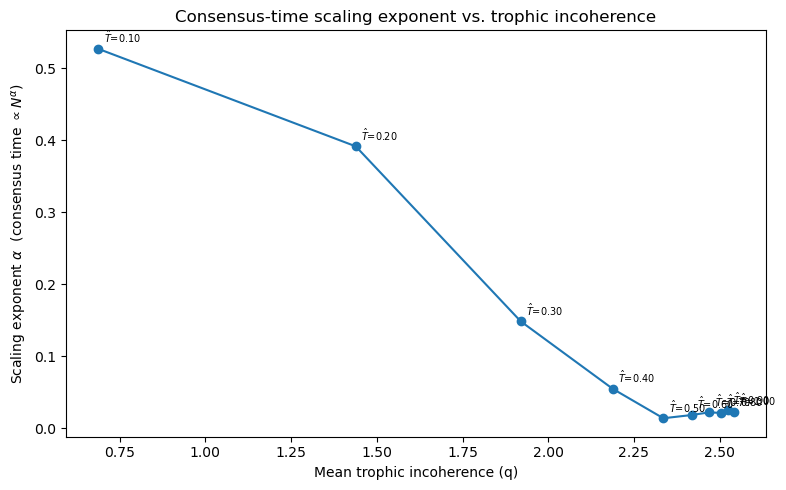

T_hat=0.10  q=0.687  alpha=0.527  C=4.314
T_hat=0.20  q=1.438  alpha=0.392  C=5.180
T_hat=0.30  q=1.920  alpha=0.149  C=12.831
T_hat=0.40  q=2.188  alpha=0.055  C=17.303
T_hat=0.50  q=2.336  alpha=0.014  C=19.645
T_hat=0.60  q=2.418  alpha=0.019  C=18.271
T_hat=0.70  q=2.469  alpha=0.022  C=17.607
T_hat=0.80  q=2.503  alpha=0.022  C=17.645
T_hat=0.90  q=2.524  alpha=0.025  C=17.204
T_hat=1.00  q=2.541  alpha=0.023  C=17.433


In [25]:
# scaling exponents: consensus_time ~ C * N^alpha per q(T) curve

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q_means, exponents, 'o-', color='tab:blue')
for q, T_hat, a in zip(q_means, T_hat_values, exponents):
    ax.annotate(fr'$\hat{{T}}$={T_hat:.2f}', (q, a), fontsize=7, textcoords='offset points', xytext=(4, 4))

ax.set_xlabel('Mean trophic incoherence (q)')
ax.set_ylabel(r'Scaling exponent $\alpha$  (consensus time $\propto N^\alpha$)')
ax.set_title('Consensus-time scaling exponent vs. trophic incoherence')
fig.tight_layout()

fig.savefig(save_path / 'scaling_exponent_byQ.png', dpi=300, bbox_inches='tight')

plt.show()

for T_hat, q, a, c in zip(T_hat_values, q_means, exponents, prefactors):
    print(f'T_hat={T_hat:.2f}  q={q:.3f}  alpha={a:.3f}  C={c:.3f}')

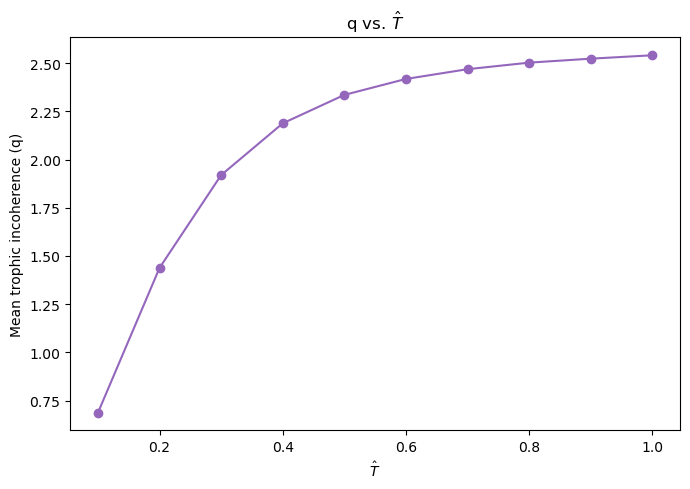

In [30]:
# T-hat vs. q directly

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(T_hat_values, q_means, 'o-', color='tab:purple')

ax.set_xlabel(r'$\hat{T}$')
ax.set_ylabel('Mean trophic incoherence (q)')
ax.set_title(r'q vs. $\hat{T}$')
fig.tight_layout()

fig.savefig(save_path / 'q_vs_T-hat.png', dpi=300, bbox_inches='tight')

plt.show()

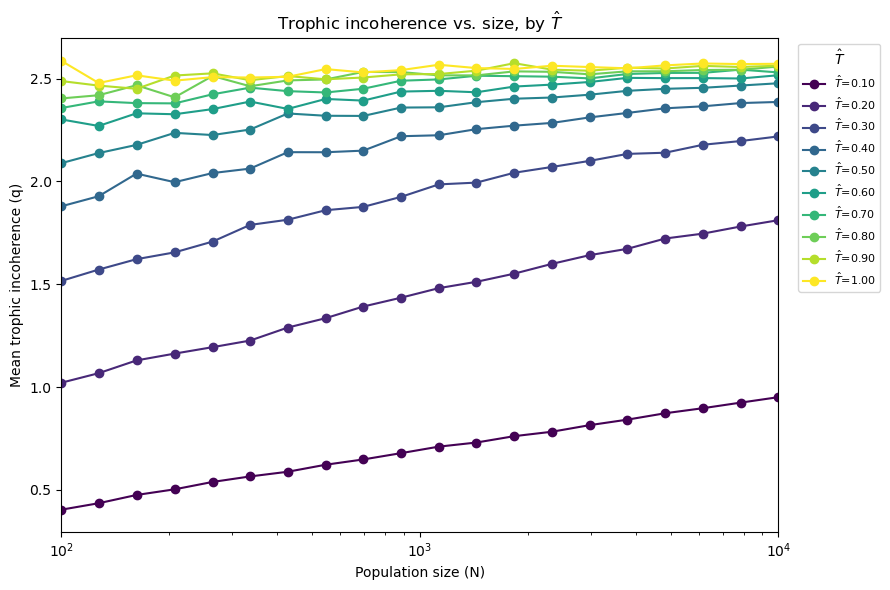

In [27]:
# trophic incoherence q vs. population size N, one line per T-hat

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('viridis')

for i, r in enumerate(records_by_T_hat):
    color = cmap(i / max(len(records_by_T_hat) - 1, 1))
    ax.plot(r['sizes'], r['q_by_size'], 'o-', label=fr'$\hat{{T}}$={r["T_hat"]:.2f}', color=color)

ax.set_xscale('log')
ax.set_xlabel('Population size (N)')
ax.set_ylabel('Mean trophic incoherence (q)')
ax.set_xlim(left=min(records_by_T_hat[0]['sizes']), right=max(records_by_T_hat[0]['sizes']))
ax.set_title(r'Trophic incoherence vs. size, by $\hat{T}$')
ax.legend(title=r'$\hat{T}$', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()

fig.savefig(save_path / 'q_vs_N_byT.png', dpi=300, bbox_inches='tight')

plt.show()

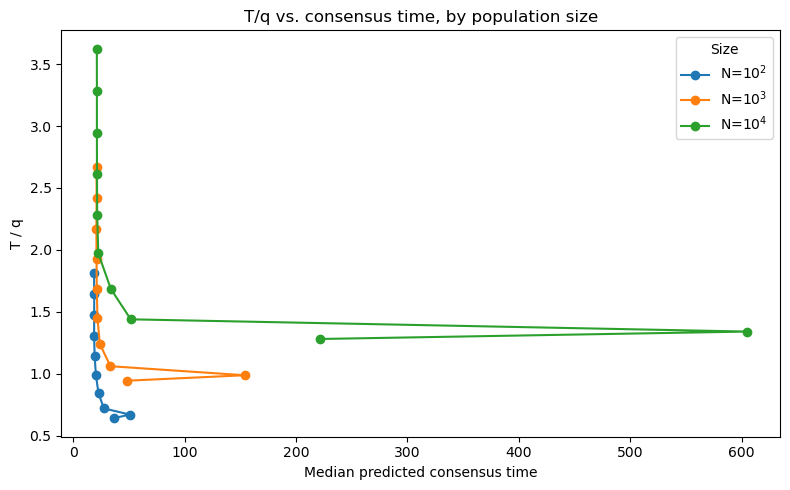

at N=10000:
T/q=3.6242  T=9.210  T_hat=1.00  q=2.541
T/q=3.2845  T=8.289  T_hat=0.90  q=2.524
T/q=2.9436  T=7.368  T_hat=0.80  q=2.503
T/q=2.6111  T=6.447  T_hat=0.70  q=2.469
T/q=2.2850  T=5.526  T_hat=0.60  q=2.418
T/q=1.9716  T=4.605  T_hat=0.50  q=2.336
T/q=1.6836  T=3.684  T_hat=0.40  q=2.188
T/q=1.4393  T=2.763  T_hat=0.30  q=1.920
T/q=1.3404  T=0.921  T_hat=0.10  q=0.687
T/q=1.2806  T=1.842  T_hat=0.20  q=1.438


In [ ]:
# Tc vs. T/q for three population sizes, using the actual T at each N
# (T = T_hat * ln(N), so T/q depends on N -- it is computed per size)
# NOTE: T_hat=0.10 has q~0 (~8.5e-11), which sends T/q to ~1.2e9 -- excluded as a degenerate outlier

recs = [r for r in records_by_T_hat if r['q_mean'] > 1e-6]

fig, ax = plt.subplots(figsize=(8, 5))
for target_N in [100, 1_000, 10_000]:
    idx = np.argmin(np.abs(sizes_grid - target_N))
    actual_N = sizes_grid[idx]

    T_over_q = np.array([r['T_by_size'][idx] / r['q_mean'] for r in recs])
    Tc = np.array([r['medians'][idx] for r in recs])

    order = np.argsort(T_over_q)
    exponent = int(round(np.log10(target_N)))
    ax.plot(Tc[order], T_over_q[order], 'o-', label=fr'N=$10^{{{exponent}}}$')

ax.set_xlabel('Median predicted consensus time')
ax.set_ylabel('T / q')
ax.set_title('T/q vs. consensus time, by population size')
ax.legend(title='Size')
fig.tight_layout()

fig.savefig(save_path / 'Tc_vs_Tq_bysize.png', dpi=300, bbox_inches='tight')

plt.show()

idx_max = len(sizes_grid) - 1
T_over_q = np.array([r['T_by_size'][idx_max] / r['q_mean'] for r in recs])
order_desc = np.argsort(T_over_q)[::-1]
print(f'at N={sizes_grid[idx_max]}:')
for i in order_desc:
    print(f'T/q={T_over_q[i]:.4f}  T={recs[i]["T_by_size"][idx_max]:.3f}  T_hat={recs[i]["T_hat"]:.2f}  q={recs[i]["q_mean"]:.3f}')

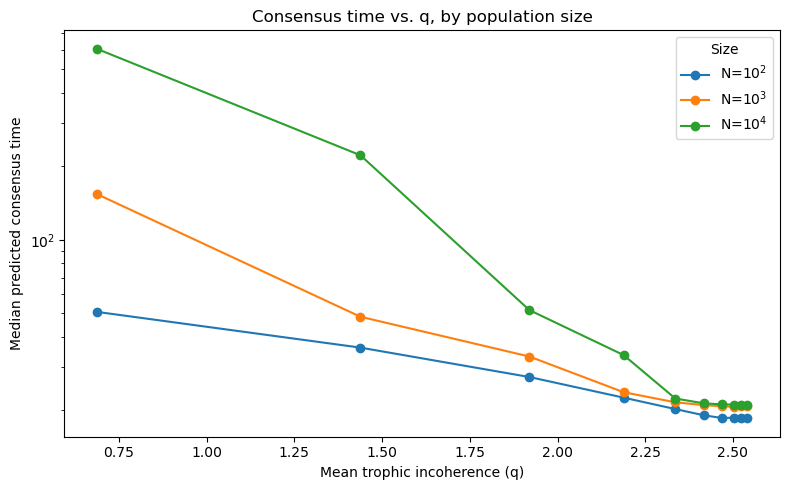

In [29]:
# Tc vs. q for three population sizes
# points connected in T-order (not sorted by q) so the rise-then-fall fold-back in q(T) is visible

fig, ax = plt.subplots(figsize=(8, 5))
for target_N in [100, 1_000, 10_000]:
    idx = np.argmin(np.abs(sizes_grid - target_N))

    q_vals = np.array([r['q_mean'] for r in records_by_T_hat])
    Tc = np.array([r['medians'][idx] for r in records_by_T_hat])

    exponent = int(round(np.log10(target_N)))
    ax.plot(q_vals, Tc, 'o-', label=fr'N=$10^{{{exponent}}}$')

ax.set_xlabel('Mean trophic incoherence (q)')
ax.set_ylabel('Median predicted consensus time')
ax.set_yscale('log')
ax.set_title('Consensus time vs. q, by population size')
ax.legend(title='Size')
fig.tight_layout()

os.makedirs('figures', exist_ok=True)
fig.savefig(save_path / 'logTc_vs_q_bysize.png', dpi=300, bbox_inches='tight')

plt.show()